## 0. Install Dependencies

In [13]:
!pip install networkx pandas matplotlib seaborn scipy -q

## 1. Imports & Config

In [14]:
import warnings
warnings.filterwarnings('ignore')

import json
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Config ────────────────────────────────────────────────────────────────
LINKS_CSV   = 'links_export.csv'   # uploaded to Colab files
SAMPLE_SIZE = 50_000               # rows to load (full file is 894MB)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Plot style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.5,
    'font.family':      'monospace',
    'figure.dpi':       130,
})
ACCENT  = '#00d4ff'
ACCENT2 = '#ff6b6b'
ACCENT3 = '#a8ff78'

print('All imports loaded ✓')

All imports loaded ✓


## 2. Load Data & Build Graph

We load `links_export.csv` which contains directed edges (`source_title` → `target_title`).  
The full file has 5.37M rows (~894MB) — we sample `SAMPLE_SIZE` rows for performance.  
Self-loops and null values are dropped as part of cleaning.

In [15]:
print(f'Loading {SAMPLE_SIZE:,} rows from {LINKS_CSV}...')

df = pd.read_csv(
    LINKS_CSV,
    usecols=['source_title', 'target_title'],
    nrows=SAMPLE_SIZE
)

# ── Cleaning ──────────────────────────────────────────────────────────────
before = len(df)
df = df.dropna(subset=['source_title', 'target_title'])
df = df[df['source_title'] != df['target_title']]  # remove self-loops
after = len(df)
print(f'Rows after cleaning: {after:,} / {before:,} (removed {before - after:,} dirty rows)')

# ── Build directed graph ──────────────────────────────────────────────────
G = nx.from_pandas_edgelist(
    df,
    source='source_title',
    target='target_title',
    create_using=nx.DiGraph()
)

print(f'\nGraph built:')
print(f'  Nodes : {G.number_of_nodes():,}')
print(f'  Edges : {G.number_of_edges():,}')
print(f'  Density: {nx.density(G):.6f}')

Loading 50,000 rows from links_export.csv...
Rows after cleaning: 49,996 / 50,000 (removed 4 dirty rows)

Graph built:
  Nodes : 41,795
  Edges : 49,996
  Density: 0.000029


## 3. Centrality Metrics

### Metric 1 — PageRank
Simulates a random surfer following links. Score flows from authoritative pages to their neighbors.  
`α = 0.85` (standard damping factor — 15% chance of jumping to a random page).

### Metric 2 — In-Degree Centrality  
Normalized count of how many articles link to each node. Ranges 0–1.

### Metric 3 — Betweenness Centrality  
Fraction of all-pairs shortest paths that pass through a node.  
We use `k=500` pivot-node approximation (exact computation is O(VE) — too slow for 30k nodes).

In [16]:
print('Computing PageRank...')
pr = nx.pagerank(G, alpha=0.85, max_iter=200, tol=1e-6)
print(f'  Done. PageRank sum = {sum(pr.values()):.6f}  (should be ~1.0)')

print('Computing In-Degree Centrality...')
in_deg_raw  = dict(G.in_degree())
n           = G.number_of_nodes()
in_deg_norm = {k: v / (n - 1) for k, v in in_deg_raw.items()}
print(f'  Done. Max in-degree = {max(in_deg_raw.values())}')

print('Computing Betweenness Centrality (k=500 approximation)...')
btwn = nx.betweenness_centrality(G, k=500, normalized=True, seed=RANDOM_SEED)
print(f'  Done.')

# ── Combine into DataFrame ────────────────────────────────────────────────
df_centrality = pd.DataFrame({
    'pagerank':       pr,
    'in_degree':      in_deg_norm,
    'in_degree_raw':  in_deg_raw,
    'betweenness':    btwn,
})
df_centrality.index.name = 'article'
df_centrality = df_centrality.sort_values('pagerank', ascending=False)

print(f'\nCentrality DataFrame shape: {df_centrality.shape}')
df_centrality.head(10)

Computing PageRank...
  Done. PageRank sum = 1.000000  (should be ~1.0)
Computing In-Degree Centrality...
  Done. Max in-degree = 100
Computing Betweenness Centrality (k=500 approximation)...
  Done.

Centrality DataFrame shape: (41795, 4)


,pagerank,in_degree,in_degree_raw,betweenness
article,,,,
ISBN (identifier),0.000040,0.002393,100,0.0
Doi (identifier),0.000032,0.001603,67,0.0
Azerbaijan,0.000031,0.000359,15,0.0
Baku,0.000031,0.000215,9,0.0
Wayback Machine,0.000029,0.001196,50,0.0
Earthquake,0.000029,0.000072,3,0.0
Chronology,0.000029,0.000048,2,0.0
Michael the Syrian,0.000029,0.000024,1,0.0
Armenian highlands,0.000029,0.000024,1,0.0


## 4. Figure 1 — In-Degree Distribution (Power Law Check)

A scale-free network (like the Web or Wikipedia) should show a power-law degree distribution on a log-log plot — a straight line, meaning a small number of pages get the vast majority of links.

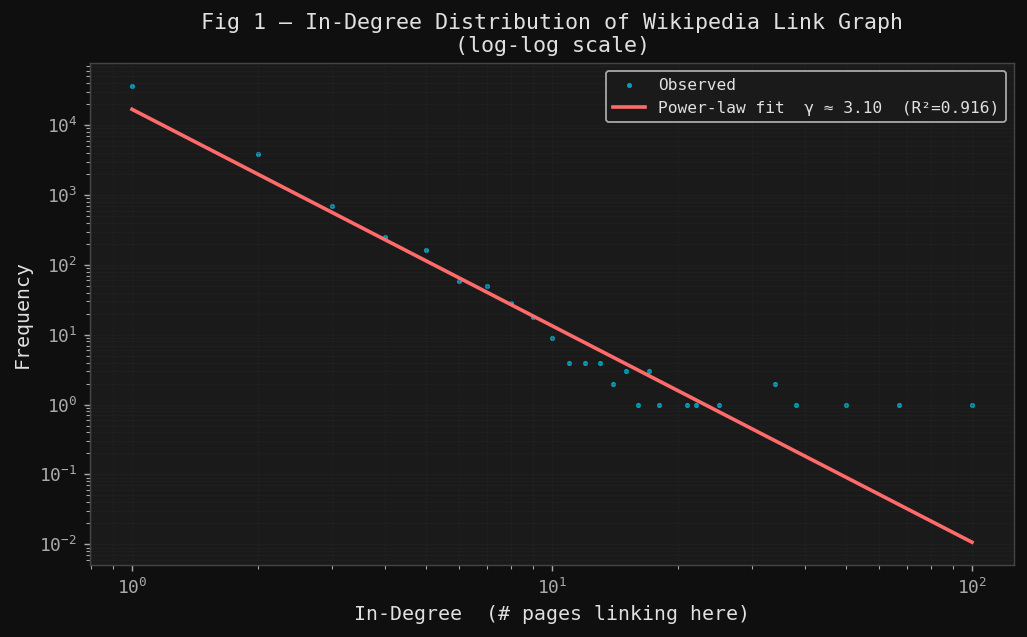

In [17]:
in_degrees = [d for _, d in G.in_degree() if d > 0]
counts     = np.bincount(in_degrees)
deg_vals   = np.nonzero(counts)[0]
freq       = counts[deg_vals]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(deg_vals, freq, s=8, color=ACCENT, alpha=0.7, linewidths=0, label='Observed')

# Power-law fit
mask = (deg_vals > 1) & (freq > 1)
if mask.sum() > 5:
    slope, intercept, r, *_ = stats.linregress(
        np.log10(deg_vals[mask]), np.log10(freq[mask])
    )
    x_fit = np.logspace(0, np.log10(deg_vals.max()), 200)
    y_fit = 10**intercept * x_fit**slope
    ax.plot(x_fit, y_fit, color=ACCENT2, lw=2,
            label=f'Power-law fit  γ ≈ {abs(slope):.2f}  (R²={r**2:.3f})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('In-Degree  (# pages linking here)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Fig 1 — In-Degree Distribution of Wikipedia Link Graph\n(log-log scale)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('fig1_degree_distribution.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 5. Figure 2 — Top 15 Articles by PageRank

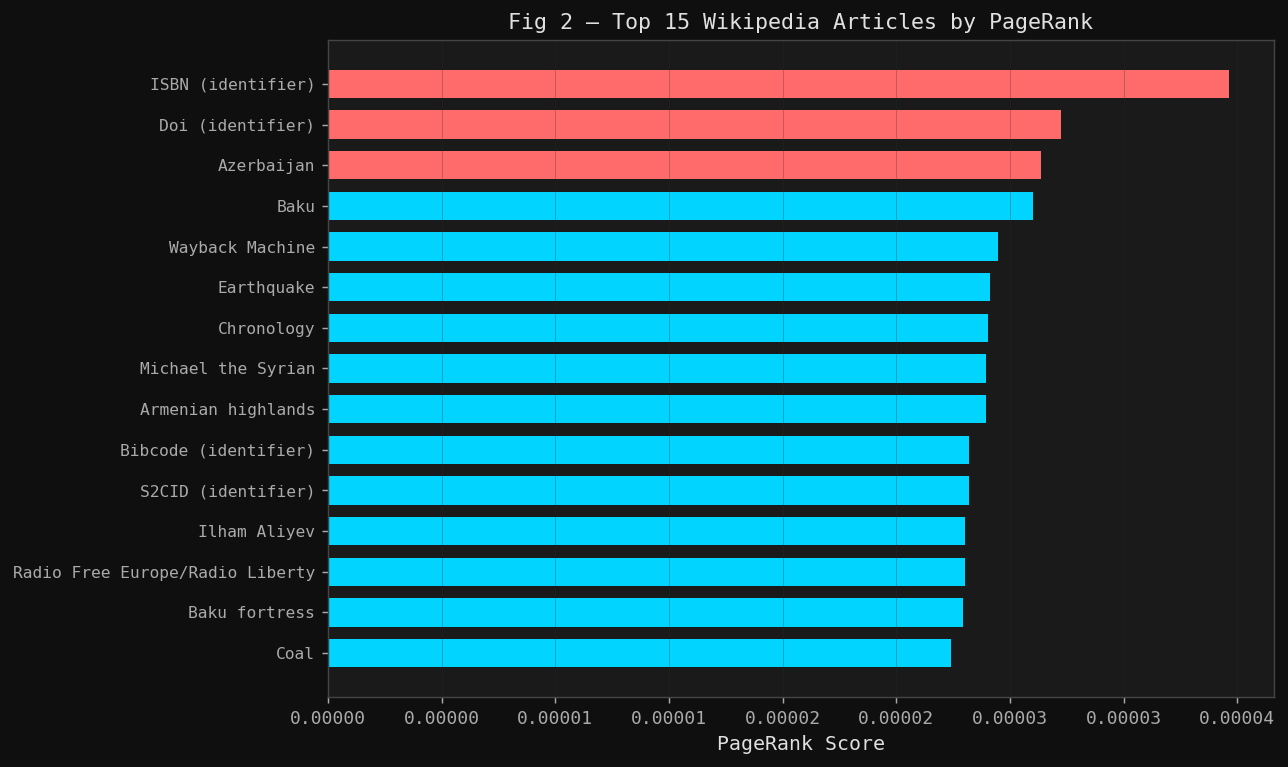

In [18]:
top_pr = df_centrality.nlargest(15, 'pagerank')[['pagerank']].iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT2 if i >= len(top_pr) - 3 else ACCENT for i in range(len(top_pr))]
ax.barh(range(len(top_pr)), top_pr['pagerank'].values,
        color=colors, edgecolor='none', height=0.7)

ax.set_yticks(range(len(top_pr)))
ax.set_yticklabels(
    [t[:55] + '…' if len(t) > 55 else t for t in top_pr.index], fontsize=9
)
ax.set_xlabel('PageRank Score', fontsize=11)
ax.set_title('Fig 2 — Top 15 Wikipedia Articles by PageRank', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_top_pagerank.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 6. Figure 3 — Top 15 Articles by Betweenness Centrality

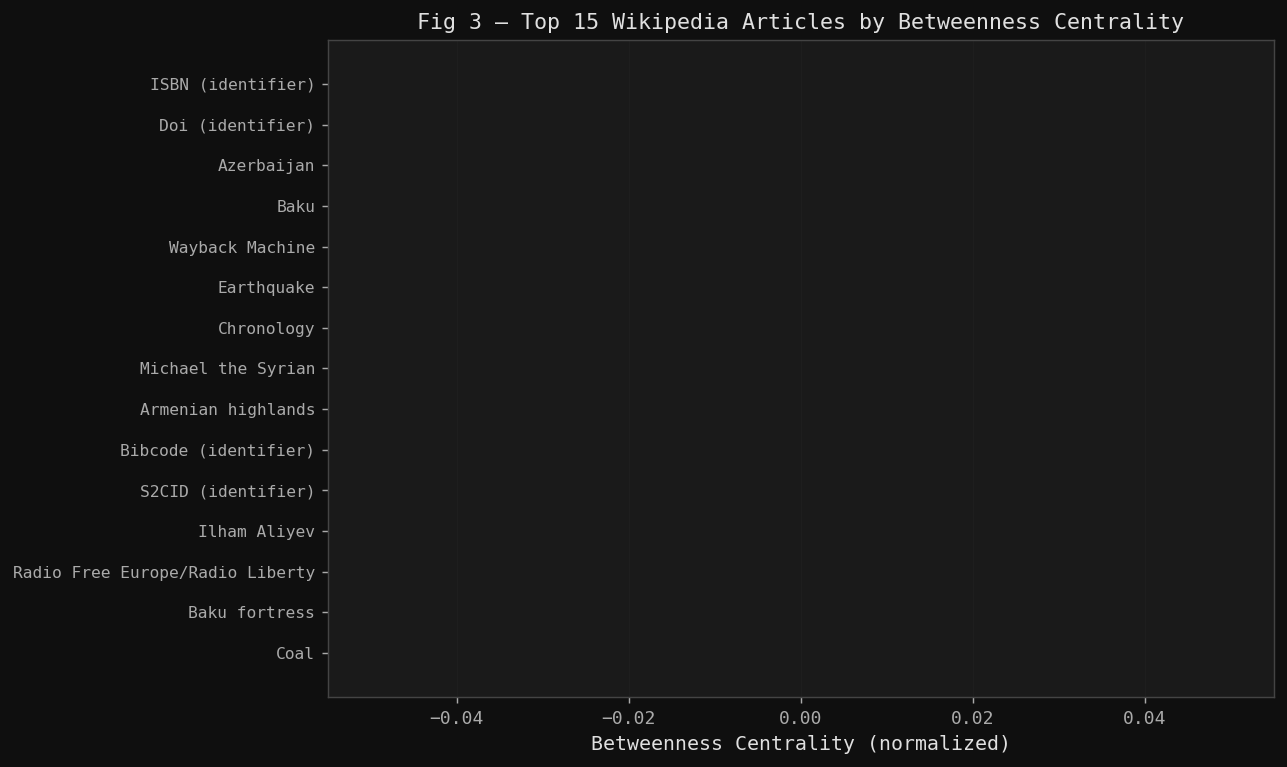

In [19]:
top_btwn = df_centrality.nlargest(15, 'betweenness')[['betweenness']].iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT2 if i >= len(top_btwn) - 3 else ACCENT3 for i in range(len(top_btwn))]
ax.barh(range(len(top_btwn)), top_btwn['betweenness'].values,
        color=colors, edgecolor='none', height=0.7)

ax.set_yticks(range(len(top_btwn)))
ax.set_yticklabels(
    [t[:55] + '…' if len(t) > 55 else t for t in top_btwn.index], fontsize=9
)
ax.set_xlabel('Betweenness Centrality (normalized)', fontsize=11)
ax.set_title('Fig 3 — Top 15 Wikipedia Articles by Betweenness Centrality', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_top_betweenness.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 7. Figure 4 — PageRank vs In-Degree Scatter

Do PageRank and In-Degree agree on who is important? Color encodes Betweenness — nodes that are high on all three metrics are the true "triple threat" hubs.

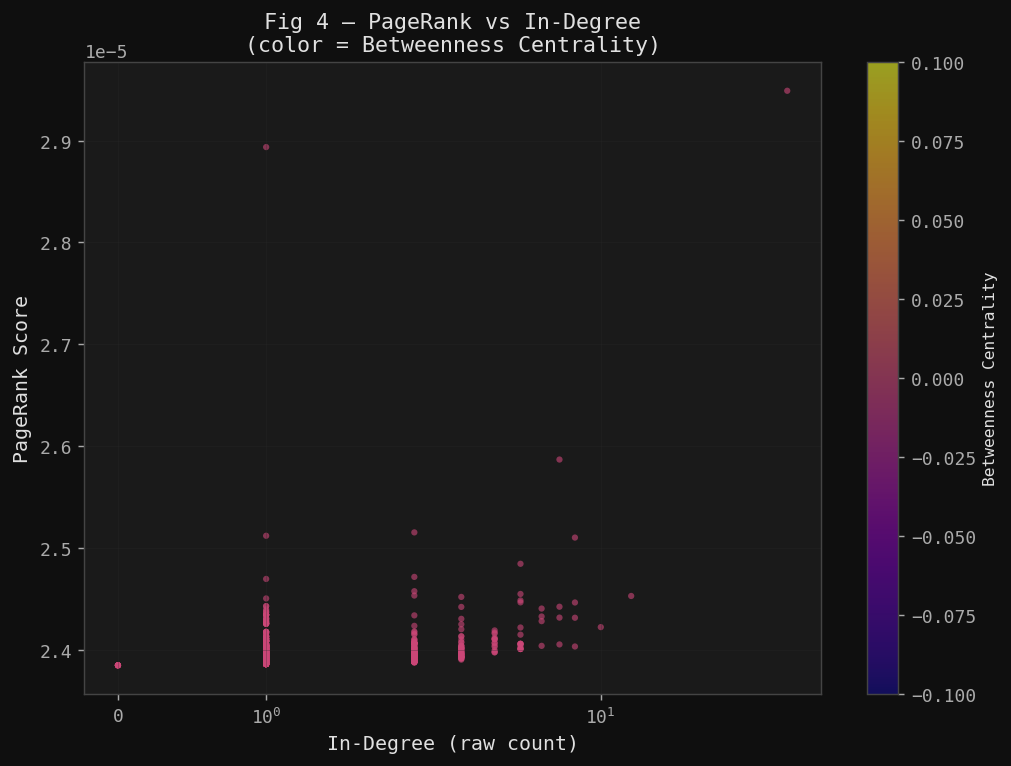

In [20]:
sample = df_centrality.sample(min(3000, len(df_centrality)), random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    sample['in_degree_raw'], sample['pagerank'],
    c=sample['betweenness'], cmap='plasma',
    s=12, alpha=0.6, linewidths=0
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Betweenness Centrality', fontsize=9)
ax.set_xlabel('In-Degree (raw count)', fontsize=11)
ax.set_ylabel('PageRank Score', fontsize=11)
ax.set_title('Fig 4 — PageRank vs In-Degree\n(color = Betweenness Centrality)', fontsize=12)
ax.set_xscale('symlog')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_centrality_scatter.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 8. Figure 5 — Centrality Metric Correlation Heatmap

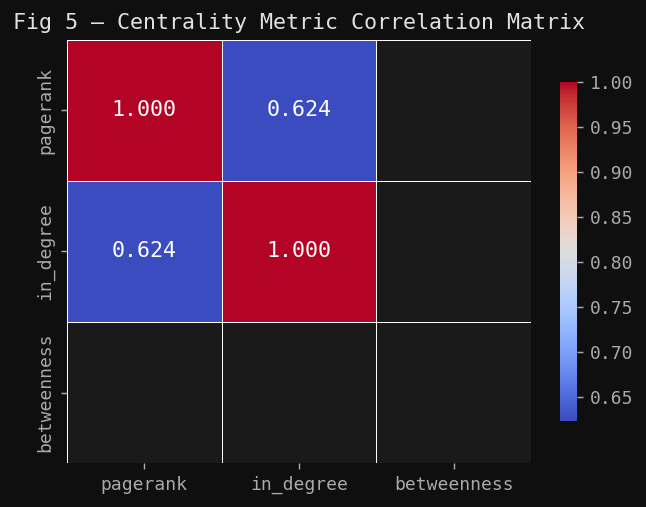


Correlation matrix:
             pagerank  in_degree  betweenness
pagerank        1.000      0.624          NaN
in_degree       0.624      1.000          NaN
betweenness       NaN        NaN          NaN


In [21]:
corr = df_centrality[['pagerank', 'in_degree', 'betweenness']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    linewidths=0.5, ax=ax,
    annot_kws={'size': 12},
    cbar_kws={'shrink': 0.8},
)
ax.set_title('Fig 5 — Centrality Metric Correlation Matrix', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

print('\nCorrelation matrix:')
print(corr.round(3))

## 9. Top Important Nodes Summary

Identifying the top nodes under each of our three importance definitions.

In [22]:
TOP_N = 10

print('=' * 65)
print(f'TOP {TOP_N} NODES BY PAGERANK')
print('=' * 65)
top_pr_table = df_centrality.nlargest(TOP_N, 'pagerank')[['pagerank', 'in_degree_raw', 'betweenness']]
top_pr_table.columns = ['PageRank', 'In-Degree (raw)', 'Betweenness']
print(top_pr_table.to_string())

print()
print('=' * 65)
print(f'TOP {TOP_N} NODES BY IN-DEGREE')
print('=' * 65)
top_id_table = df_centrality.nlargest(TOP_N, 'in_degree_raw')[['in_degree_raw', 'pagerank', 'betweenness']]
top_id_table.columns = ['In-Degree (raw)', 'PageRank', 'Betweenness']
print(top_id_table.to_string())

print()
print('=' * 65)
print(f'TOP {TOP_N} NODES BY BETWEENNESS CENTRALITY')
print('=' * 65)
top_btwn_table = df_centrality.nlargest(TOP_N, 'betweenness')[['betweenness', 'pagerank', 'in_degree_raw']]
top_btwn_table.columns = ['Betweenness', 'PageRank', 'In-Degree (raw)']
print(top_btwn_table.to_string())

TOP 10 NODES BY PAGERANK
                      PageRank  In-Degree (raw)  Betweenness
article                                                     
ISBN (identifier)     0.000040              100          0.0
Doi (identifier)      0.000032               67          0.0
Azerbaijan            0.000031               15          0.0
Baku                  0.000031                9          0.0
Wayback Machine       0.000029               50          0.0
Earthquake            0.000029                3          0.0
Chronology            0.000029                2          0.0
Michael the Syrian    0.000029                1          0.0
Armenian highlands    0.000029                1          0.0
Bibcode (identifier)  0.000028               34          0.0

TOP 10 NODES BY IN-DEGREE
                      In-Degree (raw)  PageRank  Betweenness
article                                                     
ISBN (identifier)                 100  0.000040          0.0
Doi (identifier)                 

## 10. Validation Checks

Sanity checks to ensure data integrity and correctness of analysis.

In [23]:
print('Running validation checks...\n')

# (1) PageRank must sum to ~1.0
pr_sum = df_centrality['pagerank'].sum()
status = '✓' if 0.99 < pr_sum < 1.01 else '✗ FAIL'
print(f'[{status}] PageRank sum = {pr_sum:.6f}  (expected ~1.0)')

# (2) In-degree cross-check on top article
top_article = df_centrality.index[0]
manual_indeg = G.in_degree(top_article)
stored_indeg = int(df_centrality.loc[top_article, 'in_degree_raw'])
status = '✓' if manual_indeg == stored_indeg else '✗ MISMATCH'
print(f'[{status}] Top article "{top_article[:40]}" in-degree: nx={manual_indeg}, df={stored_indeg}')

# (3) No NaN in centrality columns
nulls = df_centrality[['pagerank', 'in_degree', 'betweenness']].isnull().sum().sum()
status = '✓' if nulls == 0 else f'✗ {nulls} NaN values found'
print(f'[{status}] NaN check in centrality columns: {nulls} NaN values')

# (4) Largest weakly connected component
undirected   = G.to_undirected()
components   = list(nx.connected_components(undirected))
largest_size = max(len(c) for c in components)
frac         = largest_size / G.number_of_nodes()
print(f'[✓] Largest weakly connected component: {largest_size:,} nodes ({frac:.1%} of graph)')
print(f'    Total components: {len(components):,}')

# (5) Graph is directed
status = '✓' if G.is_directed() else '✗'
print(f'[{status}] Graph is directed: {G.is_directed()}')

print('\nAll validation checks complete.')

Running validation checks...

[✓] PageRank sum = 1.000000  (expected ~1.0)
[✓] Top article "ISBN (identifier)" in-degree: nx=100, df=100
[✓] NaN check in centrality columns: 0 NaN values
[✓] Largest weakly connected component: 41,795 nodes (100.0% of graph)
    Total components: 1
[✓] Graph is directed: True

All validation checks complete.


## 11. Export Summary CSV

In [24]:
top_pr_out   = df_centrality.nlargest(10, 'pagerank').reset_index()[['article','pagerank']].assign(metric='PageRank').rename(columns={'pagerank':'score'})
top_id_out   = df_centrality.nlargest(10, 'in_degree_raw').reset_index()[['article','in_degree_raw']].assign(metric='In-Degree').rename(columns={'in_degree_raw':'score'})
top_btwn_out = df_centrality.nlargest(10, 'betweenness').reset_index()[['article','betweenness']].assign(metric='Betweenness').rename(columns={'betweenness':'score'})

summary_df = pd.concat([top_pr_out, top_id_out, top_btwn_out], ignore_index=True)
summary_df.to_csv('top_nodes_summary.csv', index=False)
print('Saved: top_nodes_summary.csv')
summary_df.head(10)

Saved: top_nodes_summary.csv


,article,score,metric
0,ISBN (identifier),0.000040,PageRank
1,Doi (identifier),0.000032,PageRank
2,Azerbaijan,0.000031,PageRank
3,Baku,0.000031,PageRank
4,Wayback Machine,0.000029,PageRank
5,Earthquake,0.000029,PageRank
6,Chronology,0.000029,PageRank
7,Michael the Syrian,0.000029,PageRank
8,Armenian highlands,0.000029,PageRank
9,Bibcode (identifier),0.000028,PageRank
